# 05 — Modelo C: Multi-espectral (13 canais)

Usamos **todas as 13 bandas** do Sentinel-2 — incluindo NIR, red-edge (B5–B7), vapor d'água (B9), cirrus (B10) e SWIR (B11, B12). É a entrada com mais informação espectral possível.

**Tudo o mais é idêntico aos modelos A e B.** A única mudança: 13 canais de entrada.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

import numpy as np
import tensorflow as tf
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt

from src import config, data_loader as dl, models, training, evaluation
from src import visualization as viz

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)
mixed_precision.set_global_policy('mixed_float16')
tf.random.set_seed(config.SEED); np.random.seed(config.SEED)
config.ensure_dirs()

MODEL_NAME = 'model_c_multispectral'
CHANNELS = config.ALL_INDICES
print('Canais:', [config.BAND_NAMES[i] for i in CHANNELS])

I0000 00:00:1780162069.324550    1046 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Canais: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B10', 'B11', 'B12']


In [2]:
train_ds, val_ds, test_ds = dl.make_splits()
mean, std = dl.load_norm_stats()

train_pipe = dl.build_pipeline(train_ds, CHANNELS, mean, std, augment=True, shuffle=True)
val_pipe = dl.build_pipeline(val_ds, CHANNELS, mean, std, augment=False, shuffle=False)
test_pipe = dl.build_pipeline(test_ds, CHANNELS, mean, std, augment=False, shuffle=False)

I0000 00:00:1780162081.206222    1046 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:06:00.0, compute capability: 8.6


In [3]:
model = models.build_cnn(input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, len(CHANNELS)))
training.compile_model(model)
model.summary()

Model: "eurosat_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             

 Total params: 292,522 (1.12 MB)

 Trainable params: 291,626 (1.11 MB)

 Non-trainable params: 896 (3.50 KB)

In [4]:
history, train_time = training.train_model(model, train_pipe, val_pipe, MODEL_NAME)
print(f'\nTempo de treino: {train_time:.0f}s')

Epoch 1/50


I0000 00:00:1780162085.517953    1621 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
I0000 00:00:1780162088.501330    1540 service.cc:153] XLA service 0x71f3fc03f4e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780162088.501412    1540 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780162088.740881    1540 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780162089.257859    1540 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780162089.352595    1540 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5574__.99


  1/296 ━━━━━━━━━━━━━━━━━━━━ 2:05:51 26s/step - accuracy: 0.1094 - loss: 3.1531

I0000 00:00:1780162108.803205    1540 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


293/296 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7100 - loss: 0.8657

...

294/296 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9867 - loss: 0.0424
Epoch 35: val_accuracy did not improve from 0.98469
296/296 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.9877 - loss: 0.0398 - val_accuracy: 0.9810 - val_loss: 0.0520 - learning_rate: 2.5000e-04
Epoch 36/50
293/296 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9871 - loss: 0.0430
Epoch 36: val_accuracy did not improve from 0.98469
296/296 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9870 - loss: 0.0423 - val_accuracy: 0.9837 - val_loss: 0.0496 - learning_rate: 2.5000e-04
Epoch 37/50
294/296 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9859 - loss: 0.0457
Epoch 37: val_accuracy did not improve from 0.98469

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
296/296 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.9872 - loss: 0.0403 - val_accuracy: 0.9840 - val_loss: 0.0492 - learning_rate: 2.5000e-04
Epoch 38/50


I0000 00:00:1780162849.867524    9623 shuffle_dataset_op.cc:453] ShuffleDatasetV3:22: Filling up shuffle buffer (this may take a while): 1299 of 2048
I0000 00:00:1780162852.835172    9623 shuffle_dataset_op.cc:483] Shuffle buffer filled.


293/296 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9864 - loss: 0.0383
Epoch 38: val_accuracy improved from 0.98469 to 0.98617, saving model to results/models/model_c_multispectral.keras

Epoch 38: finished saving model to results/models/model_c_multispectral.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 61s 146ms/step - accuracy: 0.9884 - loss: 0.0367 - val_accuracy: 0.9862 - val_loss: 0.0418 - learning_rate: 1.2500e-04
Epoch 39/50
292/296 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9898 - loss: 0.0348
Epoch 39: val_accuracy did not improve from 0.98617
296/296 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9896 - loss: 0.0328 - val_accuracy: 0.9849 - val_loss: 0.0436 - learning_rate: 1.2500e-04
Epoch 40/50
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9891 - loss: 0.0339
Epoch 40: val_accuracy did not improve from 0.98617
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9896 - loss: 0.0336 - val_accuracy: 0.9854 - val_loss: 0.0437 - learning_rate: 1.2500e-04
Epoch 

I0000 00:00:1780162987.565711   10585 shuffle_dataset_op.cc:453] ShuffleDatasetV3:22: Filling up shuffle buffer (this may take a while): 719 of 2048
I0000 00:00:1780162992.446849   10585 shuffle_dataset_op.cc:483] Shuffle buffer filled.


292/296 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9897 - loss: 0.0309
Epoch 43: val_accuracy did not improve from 0.98667

Epoch 43: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
296/296 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.9900 - loss: 0.0315 - val_accuracy: 0.9857 - val_loss: 0.0421 - learning_rate: 1.2500e-04
Epoch 44/50
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9898 - loss: 0.0320
Epoch 44: val_accuracy improved from 0.98667 to 0.98691, saving model to results/models/model_c_multispectral.keras

Epoch 44: finished saving model to results/models/model_c_multispectral.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9906 - loss: 0.0304 - val_accuracy: 0.9869 - val_loss: 0.0410 - learning_rate: 6.2500e-05
Epoch 45/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9896 - loss: 0.0323
Epoch 45: val_accuracy did not improve from 0.98691
296/296 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.9908 - loss: 0.0294 -

## Avaliação no teste

In [5]:
metrics = evaluation.evaluate_on_test(model, test_pipe)
print(f"Acurácia (teste): {metrics['accuracy']:.4f}")
print(f"F1 macro (teste): {metrics['f1_macro']:.4f}")
print()
print(evaluation.get_classification_report(metrics['y_true'], metrics['y_pred']))

Acurácia (teste): 0.9862
F1 macro (teste): 0.9852

                      precision    recall  f1-score   support

          AnnualCrop     0.9789    0.9766    0.9777       427
              Forest     0.9935    0.9978    0.9956       458
HerbaceousVegetation     0.9774    0.9774    0.9774       442
             Highway     0.9796    0.9821    0.9809       392
          Industrial     0.9900    0.9900    0.9900       402
             Pasture     0.9721    0.9654    0.9688       289
       PermanentCrop     0.9777    0.9804    0.9790       357
         Residential     1.0000    0.9978    0.9989       452
               River     0.9862    0.9862    0.9862       362
             SeaLake     0.9979    0.9979    0.9979       469

            accuracy                         0.9862      4050
           macro avg     0.9853    0.9852    0.9852      4050
        weighted avg     0.9862    0.9862    0.9862      4050



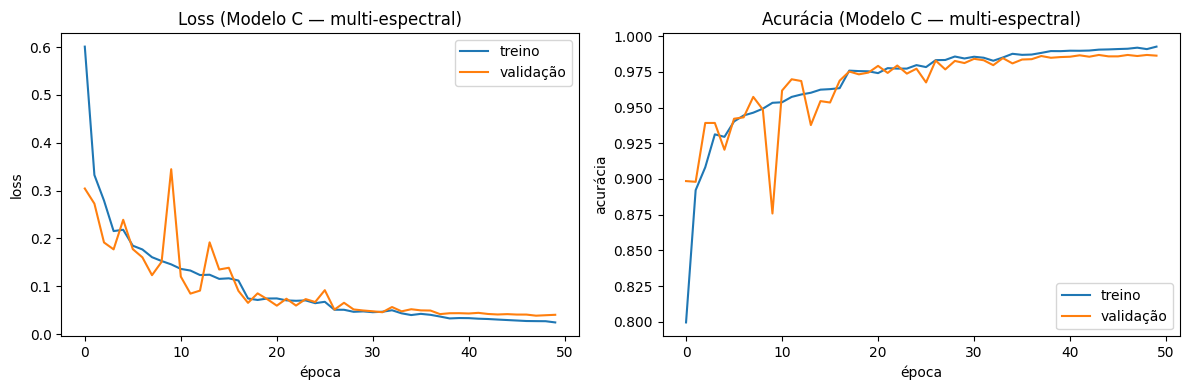

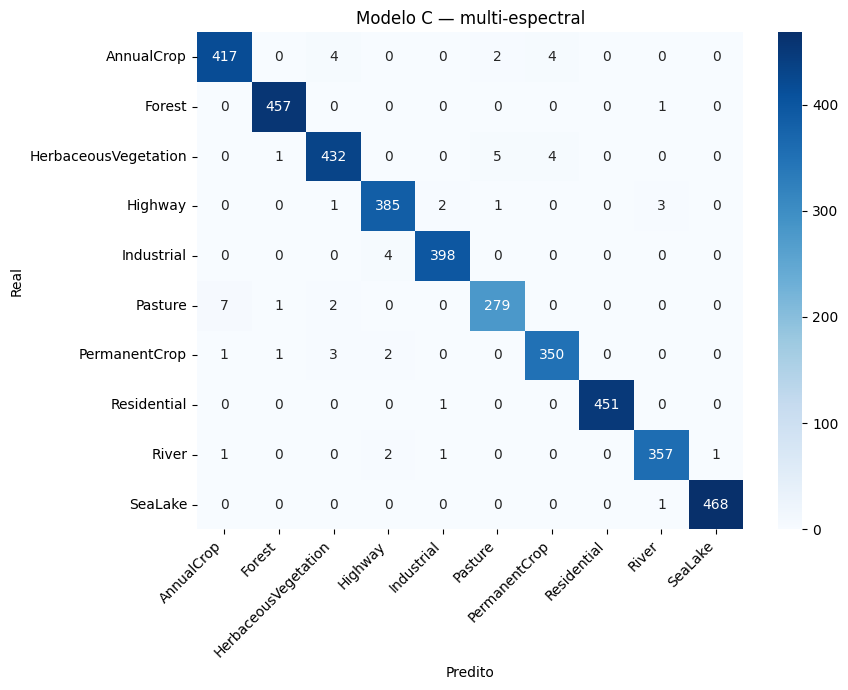

In [6]:
viz.plot_learning_curves(history, save_path=config.FIGURES_DIR / f'{MODEL_NAME}_curves.png', title_suffix='(Modelo C — multi-espectral)')
plt.show()

cm, _ = evaluation.compute_confusion_matrix(metrics['y_true'], metrics['y_pred'])
viz.plot_confusion_matrix(cm, save_path=config.FIGURES_DIR / f'{MODEL_NAME}_confusion.png', title='Modelo C — multi-espectral')
plt.show()

In [7]:
metrics['train_time_s'] = float(train_time)
metrics['num_params'] = int(model.count_params())
metrics['channels'] = [config.BAND_NAMES[i] for i in CHANNELS]
evaluation.save_metrics(metrics, config.METRICS_DIR / f'{MODEL_NAME}.json')

with open(config.HISTORIES_DIR / f'{MODEL_NAME}.json', 'w') as f:
    json.dump(history.history, f, indent=2)
print('Resultados salvos para', MODEL_NAME)

Resultados salvos para model_c_multispectral


**Próximo passo:** `06_presentation.ipynb` — consolida os 3 experimentos.